# Wine Quality EDA - Kirmizi Sarap Kalitesini Etkileyen Faktorler
Bu calismada kirmizi sarap kalitesini etkileyen kimyasal ozellikleri veri odakli olarak inceliyoruz. Hedef, hem veri okuryazarligini hem de EDA yaklasimini net bir hikaye ile gostermek.

## Amac
Bu analiz su soruya yanit ariyor: **Kirmizi sarap kalitesini belirleyen kimyasal ozellikler nelerdir?**
Amac, kalite skorunu en cok etkileyen degiskenleri bulmak ve sonraki modelleme adimlari icin anlamli bir feature onceligi cikarmaktir.

## Veri Seti
Kaynak: Kaggle - Wine Quality (Red Wine) / WineQT.csv
- Hedef degisken: `quality` (0-10 olcegi; bu veri setinde pratikte 3-8 araliginda)
- Ozellikler: 11 kimyasal olcum
- Satir/sutun bilgisi asagida dogrudan veri uzerinden hesaplanacaktir.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv('WineQT.csv')

## Kesif
Veriyi anlamak icin once genel gorunum, tipler, boyut, eksik veri ve duplicate kontrolu yapiyoruz.

Verinin ilk satirlarina bakarak kolonlari ve degerlerin genel akisina hizli bir ilk bakis atiyoruz.

In [26]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Tipleri ve veri boyutunu birlikte kontrol ederek analize uygunluk ve olasi donusum ihtiyacini degerlendiriyoruz.

In [27]:
df.info()
print('Shape:', df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
Shape: (1143, 13)


Eksik gozlem ve tekrar eden kayitlarin durumunu kontrol ederek veri kalitesi tarafini netlestiriyoruz.

In [28]:
missing_counts = df.isnull().sum()
duplicate_count = df.duplicated().sum()

display(missing_counts)
print('Duplicate row count:', duplicate_count)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Duplicate row count: 0


Hedef degiskenin dagilimini gormek, yorum yaparken hangi kalite skorlarinin agirlikta oldugunu anlamayi saglar.

In [29]:
display(df['quality'].value_counts().sort_index())
print('Quality classes:', sorted(df['quality'].unique()))

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64

Quality classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


## Korelasyon Analizi
Hangi ozellikler `quality` ile guclu bir iliski kuruyor? Bu soruya korelasyon matrisi ile yanit ariyoruz.

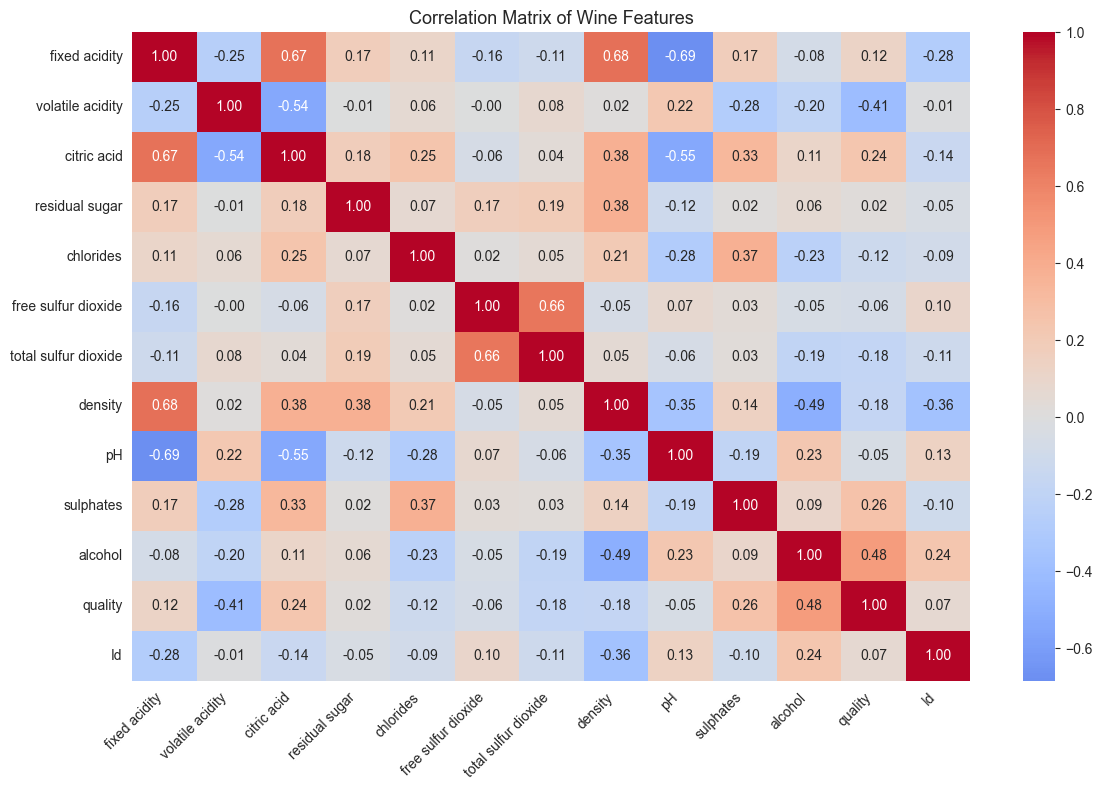

In [30]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Wine Features', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

**Bulgu Ozeti:**
- `alcohol` ile `quality`: **+0.48** (en guclu pozitif iliski)
- `volatile acidity` ile `quality`: **-0.41** (en guclu negatif iliski)
- `sulphates` ile `quality`: **+0.26** (orta duzey pozitif iliski)

## Kalite Bazli Dagilimlar (Box Plot)
Uc kritik degiskeni ayni figurde karsilastirarak kalite seviyelerine gore dagilim farklarini goruyoruz.

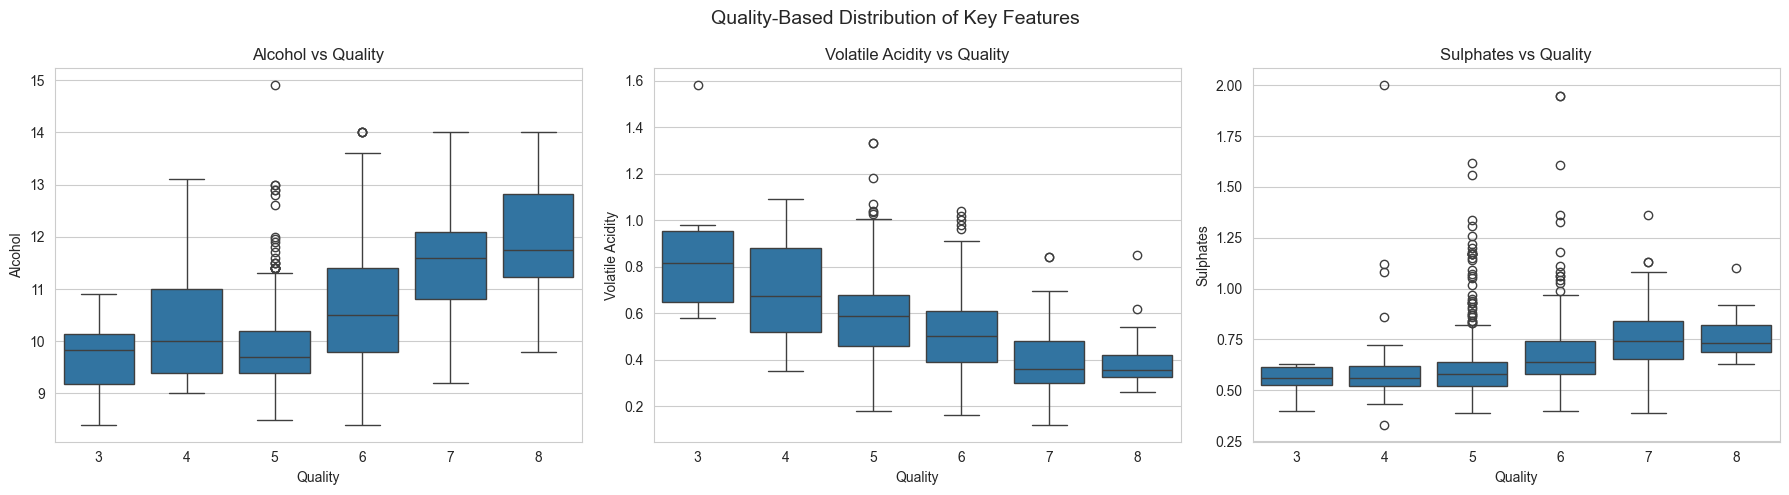

In [31]:
sns.set_style('whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='quality', y='alcohol', data=df, ax=axes[0])
axes[0].set_title('Alcohol vs Quality')
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Alcohol')

sns.boxplot(x='quality', y='volatile acidity', data=df, ax=axes[1])
axes[1].set_title('Volatile Acidity vs Quality')
axes[1].set_xlabel('Quality')
axes[1].set_ylabel('Volatile Acidity')

sns.boxplot(x='quality', y='sulphates', data=df, ax=axes[2])
axes[2].set_title('Sulphates vs Quality')
axes[2].set_xlabel('Quality')
axes[2].set_ylabel('Sulphates')

fig.suptitle('Quality-Based Distribution of Key Features', fontsize=14)
plt.tight_layout()

Kisa yorumlar:
- Yuksek kaliteli saraplarda alkol seviyesinin daha yukarida toplandigi net goruluyor.
- Volatile acidity kalite arttikca genelde dusuyor; bu, daha temiz tat profiliyle uyumlu bir sinyal veriyor.
- Sulphates dagiliminda ust kalite segmentlerinde yukari kayma var, ancak etkisi alkol kadar keskin degil.

## Degisken Dagilimlari
Her kimyasal ozelligin `quality` gruplarina gore dagilimini bir arada gormek icin 4x4 KDE grid kullaniyoruz.

C:\Users\yusa9\AppData\Local\Temp\ipykernel_18788\2965010352.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=column, hue='quality', ax=ax[i], common_norm=False)


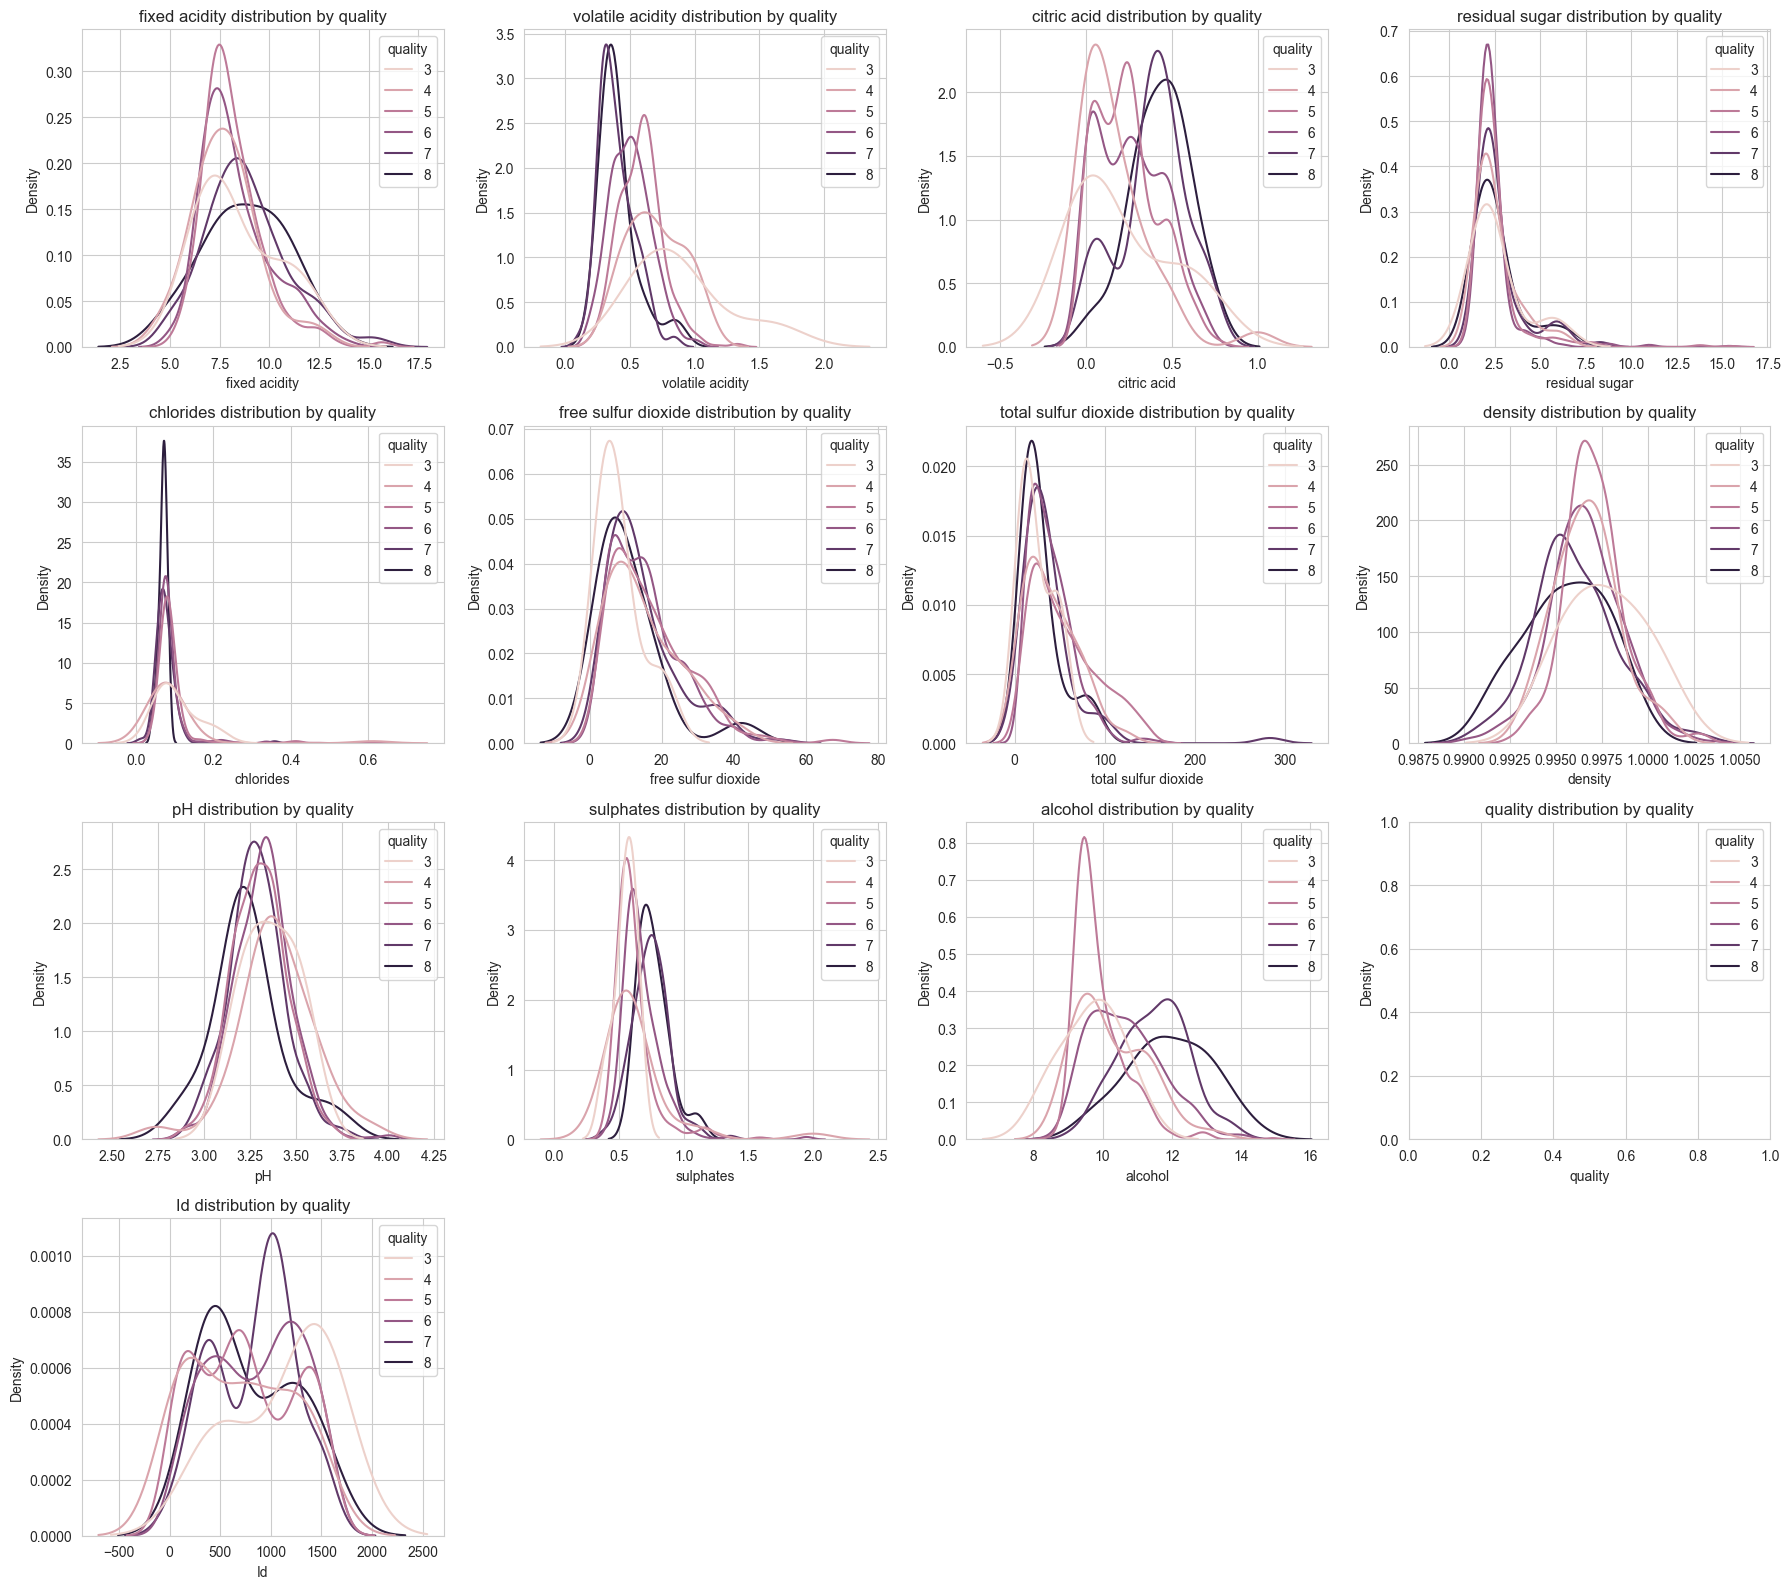

In [32]:
columns = df.columns
fig, ax = plt.subplots(4, 4, figsize=(18, 16))
ax = ax.flatten()

for i, column in enumerate(columns):
    sns.kdeplot(data=df, x=column, hue='quality', ax=ax[i], common_norm=False)
    ax[i].set_title(f'{column} distribution by quality')

for j in range(i + 1, len(ax)):
    ax[j].axis('off')

plt.tight_layout()

## Sonuc ve Bulgular
- Yuksek alkol seviyesi daha yuksek kalite ile guclu sekilde birlikte hareket ediyor.
- Yuksek volatile acidity dusuk kalite ile iliskili; kaliteyi asagi ceken en belirgin sinyallerden biri.
- Sulphates tarafinda pozitif bir iliski var; koruyucu etki kaliteye katkida bulunuyor olabilir.
- Korelasyon ve dagilim grafikleri birlikte okundugunda kalite siniflari arasinda ayristirici feature sinyali mevcut.

**Bir sonraki adim (ML odagi):** `alcohol`, `volatile acidity`, `sulphates`, `citric acid` ve `density` ozellikleri ile baseline bir model kurulabilir (or. RandomForest, XGBoost).

In [33]:
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    print(f'Data quality note: {duplicate_count} duplicate rows detected. Consider deduplication before modeling.')
else:
    print('Data quality note: No duplicate rows detected.')

feature_priority = corr['quality'].drop('quality').abs().sort_values(ascending=False).head(5)
print('Top 5 priority features for ML:')
display(feature_priority)

Data quality note: No duplicate rows detected.
Top 5 priority features for ML:


alcohol                 0.484866
volatile acidity        0.407394
sulphates               0.257710
citric acid             0.240821
total sulfur dioxide    0.183339
Name: quality, dtype: float64

## Teknik Notlar
- Kullanilan kutuphaneler ve surumleri asagidaki hucrede raporlanmistir.
- Veri kaynagi: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

In [34]:
print('pandas version:', pd.__version__)
print('seaborn version:', sns.__version__)
print('matplotlib version:', plt.matplotlib.__version__)

pandas version: 3.0.2
seaborn version: 0.13.2
matplotlib version: 3.10.8
